# Chapter 10. Data Aggregation and Group Operations
- After loading, merging, and preparing a dataset, you may need to compute group satistics or possibly *pivot tables** for reporting or visualization purposes.
- Pandas provides a flexible ***groupby*** interface, enabling you to slice, dice, and summarize datasets in a natural way.

> - **Split a pandas object** into pieces using one or more keys (in the form of **functions, arrays, or DataFrame column names**)
> - **Calculate group summary statistics**, like count, mean, or standard deviation, or a user-defined function
> - Apply **within-group** transformations or other manipulations, like **normalization, linear regression, rank, or subset selection**
> - Compute pivot tables and cross-tabulations
> - Perform **quantile analysis** and other statistical group analyses

In [1]:
import pandas as pd
import numpy as np

## 10.4 Group Transforms and "Unwrapped" GroupBys
- There is another built-in method called ***transform***, which is similar to ***apply***, but imposes more constraints on the kind of function you can use:
    > - It can produce a scalar value to be broadcast to the shape of the group.
    > - It can produce an object of the same shape as the input group.
    > - It must not mutate its input

In [17]:
df = pd.DataFrame({'key':['a','b','c']*4, 'value':np.arange(12)})
df

,key,value
0,a,0
1,b,1
2,c,2
3,a,3
4,b,4
5,c,5
6,a,6
7,b,7
8,c,8
9,a,9


In [18]:
g = df.groupby('key')['value']
g.mean()

key
a    4.5
b    5.5
c    6.5
Name: value, dtype: float64

> - Suppose instead we wanted to produce a Series of the **same shape as df['value'], but with values replaced by the average grouped by 'key'**.
> - Like ***apply, transform*** works with functions that return Series, but the result **must be the same size as the input**.
> - Built-in aggregate functions like ***'mean'*** or ***'sum'*** are often **much faster than a general *apply* function**. These **also have a "fater path"** when used with ***transform***.

In [19]:
def get_mean(group):
    return group.mean()
g.transform(get_mean) 
# for built-in aggregation functions, 
# we can pass a string alias as with the GroupBy agg method:
# = g.transform('mean')

0     4.5
1     5.5
2     6.5
3     4.5
4     5.5
5     6.5
6     4.5
7     5.5
8     6.5
9     4.5
10    5.5
11    6.5
Name: value, dtype: float64

> - To perform ***unwrapped* group operation**:

In [25]:
normalized = (df['value'] - g.transform('mean')) / g.transform('std')

In [26]:
normalized

0    -1.161895
1    -1.161895
2    -1.161895
3    -0.387298
4    -0.387298
5    -0.387298
6     0.387298
7     0.387298
8     0.387298
9     1.161895
10    1.161895
11    1.161895
Name: value, dtype: float64

- 위 계산 직접 해보기
- **Arithmetic between the outputs of multiple GroupBy operations** instead of writing a function and passing it to *groupby(...).apply*. That is what is meant by ***"unwrapped"***.

## 10.5 Pivot Tables and Cross-Tabulation
- "Pivot Table" : Aggregating a table of data by one or more keys, **arranging the data in a rectangular with some of the group keys** along the rows and some along the columns.
    > 1. groupby + reshape with hierarchical indexing
    > 2. DataFrame also has a ***pivot_table*** method.
    > 3. There is also a top-level ***pandas.pivot_table*** function.

In [7]:
tips = pd.read_csv('Examples/tips.csv')

# Add tip percentage of total bill
tips['tip_pct'] = tips['tip']/tips['total_bill']
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.059447
1,10.34,1.66,No,Sun,Dinner,3,0.160542
2,21.01,3.50,No,Sun,Dinner,3,0.166587
3,23.68,3.31,No,Sun,Dinner,2,0.139780
4,24.59,3.61,No,Sun,Dinner,4,0.146808


In [3]:
tips.pivot_table(index=['day','smoker'])

size       tip   tip_pct  total_bill
day  smoker                                          
Fri  No      2.250000  2.812500  0.151650   18.420000
     Yes     2.066667  2.714000  0.174783   16.813333
Sat  No      2.555556  3.102889  0.158048   19.661778
     Yes     2.476190  2.875476  0.147906   21.276667
Sun  No      2.929825  3.167895  0.160113   20.506667
     Yes     2.578947  3.516842  0.187250   24.120000
Thur No      2.488889  2.673778  0.160298   17.113111
     Yes     2.352941  3.030000  0.163863   19.190588

= ***tips.groupby(['day','smoker']).mean()*** 

> - Taking the average of only ***tip_pct*** and ***size***, and additionally **group by *time***: + 'smoker' columns

In [5]:
tips.pivot_table(index=['time','day'], columns='smoker',
                 values=['tip_pct','size'], margins=True)
# To include partial totals by passing "margins=True"

size                       tip_pct                    
smoker             No       Yes       All        No       Yes       All
time   day                                                             
Dinner Fri   2.000000  2.222222  2.166667  0.139622  0.165347  0.158916
       Sat   2.555556  2.476190  2.517241  0.158048  0.147906  0.153152
       Sun   2.929825  2.578947  2.842105  0.160113  0.187250  0.166897
       Thur  2.000000       NaN  2.000000  0.159744       NaN  0.159744
Lunch  Fri   3.000000  1.833333  2.000000  0.187735  0.188937  0.188765
       Thur  2.500000  2.352941  2.459016  0.160311  0.163863  0.161301
All          2.668874  2.408602  2.569672  0.159328  0.163196  0.160803

> - To use an aggregation function other than ***mean***, **pass it to the *aggfunc* keyword argument

In [6]:
tips.pivot_table(index=['time','smoker'], columns='day',
                 values='tip_pct', aggfunc=len, margins=True)

day             Fri   Sat   Sun  Thur  All
time   smoker                             
Dinner No       3.0  45.0  57.0   1.0  106
       Yes      9.0  42.0  19.0   NaN   70
Lunch  No       1.0   NaN   NaN  44.0   45
       Yes      6.0   NaN   NaN  17.0   23
All            19.0  87.0  76.0  62.0  244

- ***count*** will exclude null values, while ***len*** will not

> 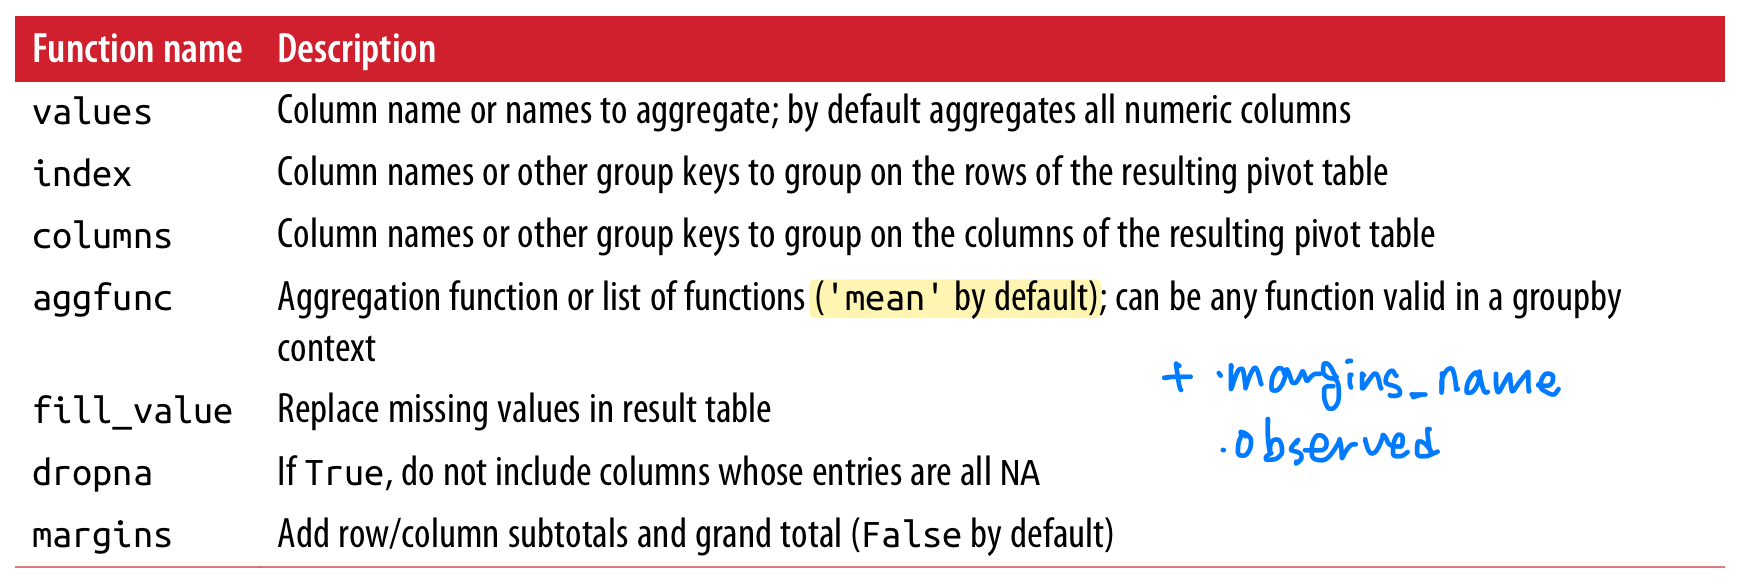

### Cross-Tabulations: Crosstab
- A **cross-tabulation**(or ***crosstab*** for short) is a special case of a pivot table that computes **group frequencies**.

In [4]:
from io import StringIO
data = """Sample  Nationality  Handedness
1   USA  Right-handed
2   Japan    Left-handed
3   USA  Right-handed
4   Japan    Right-handed
5   Japan    Left-handed
6   Japan    Right-handed
7   USA  Right-handed
8   USA  Left-handed
9   Japan    Right-handed
10  USA  Right-handed"""

data = pd.read_table(StringIO(data), sep="\s+")
data

,Sample,Nationality,Handedness
0,1,USA,Right-handed
1,2,Japan,Left-handed
2,3,USA,Right-handed
3,4,Japan,Right-handed
4,5,Japan,Left-handed
5,6,Japan,Right-handed
6,7,USA,Right-handed
7,8,USA,Left-handed
8,9,Japan,Right-handed
9,10,USA,Right-handed


> - ***pandas.crosstab*** function can be used for summarizing the data
> - The first two arguments to ***crosstab*** can each be an **array** or **Series** or a **list of arrays**.

In [6]:
pd.crosstab(data['Nationality'], data['Handedness'], margins=True)

Handedness,Left-handed,Right-handed,All
Nationality,,,
Japan,2,3,5
USA,1,4,5
All,3,7,10


In [11]:
# list of arrays
pd.crosstab([tips['time'],tips['day']], tips['smoker'], margins=True)

smoker        No  Yes  All
time   day                
Dinner Fri     3    9   12
       Sat    45   42   87
       Sun    57   19   76
       Thur    1    0    1
Lunch  Fri     1    6    7
       Thur   44   17   61
All          151   93  244